Phân tích kết quả đồ án

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_density = pd.read_csv('../results/traffic_density_analysis.csv', index_index='Time_Slot')

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

for column in df_density.columns:
    plt.plot(df_density.index, df_density[column], marker='o', label=column, linewidth=2)

plt.title("BIỂU ĐỒ PHÂN TÍCH TẦN SUẤT LƯU LƯỢNG PHƯƠNG TIỆN THEO THỜI GIAN", fontsize=14, fontweight='bold')
plt.xlabel("Mốc thời gian phân tích (Phút)", fontsize=12)
plt.ylabel("Số lượng phương tiện lưu thông / Phút", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Phân loại xe")
plt.tight_layout()

plt.savefig('../results/traffic_frequency_chart.png', dpi=300)
plt.show()

Giả lập Luồng Di chuyển và Cấu hình Đường vạch

In [ ]:
import os
import sys

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.append(os.getcwd())

Kết quả logic: Cắt vạch = True | Hướng = 1


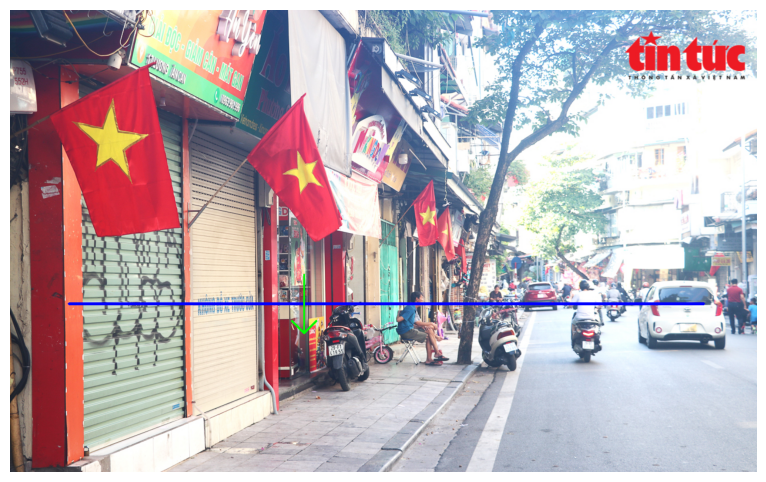

In [10]:
import cv2
import matplotlib.pyplot as plt
from src.utils import check_intersection, get_direction
from src import config as cfg

img = cv2.imread("test.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

line_start = cfg.LINE_START
line_end = cfg.LINE_END

cv2.line(img_rgb, line_start, line_end, (0, 0, 255), 3)

track_start = (500, 450) 
track_end = (500, 550)

is_intersect = check_intersection(line_start, line_end, track_start, track_end)
direction = get_direction(line_start, line_end, track_start, track_end)

color = (0, 255, 0) if is_intersect else (255, 0, 0)
cv2.arrowedLine(img_rgb, track_start, track_end, color, 2, tipLength=0.3)

print(f"Kết quả logic: Cắt vạch = {is_intersect} | Hướng = {direction}")

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

Kiểm tra Bounding Box

In [11]:
import os
import sys

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

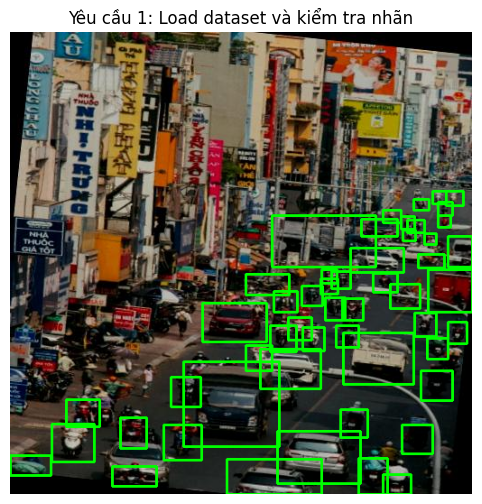

In [12]:
import cv2
import matplotlib.pyplot as plt

img_dir = "data/processed/train/images"
lbl_dir = "data/processed/train/labels"

img_list = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]

if not img_list:
    print("Không tìm thấy ảnh nào trong thư mục!")
else:
    img_path = os.path.join(img_dir, img_list[0])
    lbl_path = os.path.join(lbl_dir, img_list[0].rsplit('.', 1)[0] + '.txt')

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f.readlines():
                cls, x, y, nw, nh = map(float, line.split())
                x1, y1 = int((x - nw/2) * w), int((y - nh/2) * h)
                x2, y2 = int((x + nw/2) * w), int((y + nh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title("Yêu cầu 1: Load dataset và kiểm tra nhãn")
    plt.axis('off')
    plt.show()